# Lab 02: Where Is the Star, and How Sure Are You Allowed to Be?

**ASTR 457, Fall 2026, posted Thu Sep 10, due Wed Sep 16 by Noon (fork → PR, as always)**

*Why this lab: centroiding is how every position in every catalog you'll ever use was measured, and the Cramér–Rao bound is the professional's sanity check (the best precision any measurement can claim) that tells you instantly when an error bar in a paper (or from an AI) is too good to be true.*

Every one of you has your own dataset: `data/<your netid>.csv`, with a single column `x`,
the arrival positions, in pixels, of individual photons on a 1-D detector window spanning
$[0, 64]$ px. Most of the photons come from a star whose image on the detector is a Moffat
profile centered at $x_0$, with shape parameters $\beta = 2.5$ and $r_0 = 4$ px (both known
to you). The rest are **background**: a fraction $f_{\rm bg}$ of the photons, spread uniformly
across the window. I know the true $x_0$ and $f_{\rm bg}$ for your dataset. You don't, and you
can't look them up, and your classmates' values are different from yours. (So are their photon
counts, so your Part 2 bound is yours alone.)

**How this is graded.** Not on whether your code runs, but on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$x_0$ and $f_{\rm bg}$ are to your truth **in units of your own reported uncertainty**. Report
tiny error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.
And this week there is a floor under "huge": your reported $\sigma_{x_0}$ may not exceed
**3× the Cramér–Rao bound** you compute in Part 2. An error bar bigger than that is not
caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive estimator (15%)

Load your photon list and plot a histogram of the arrival positions (choose your binning
deliberately, and you'll defend it). Then estimate the star's position the obvious way: the
**sample mean** of all the photon positions, with uncertainty $s/\sqrt{N}$ (the standard
error of the mean). Report $\hat{x}_0 \pm \sigma$.

Then answer, in a few sentences: is this estimator biased for *your* dataset, and why?
Which way does the bias pull, and what controls its size? (This estimator is *supposed* to
be biased. Understanding exactly how (and what the background has to do with it) is the
point.)

The star's position using the naive estimator is 26.725 ± 0.377


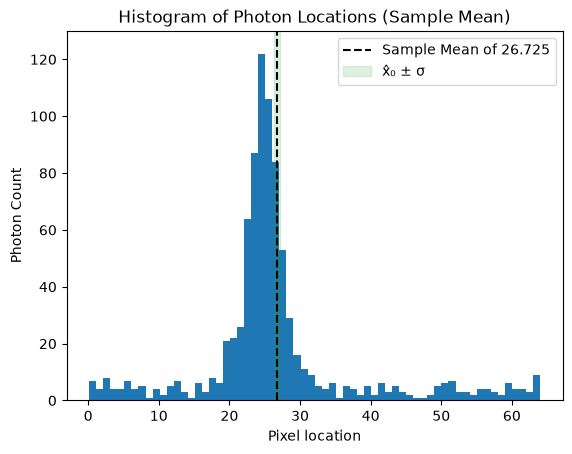

In [210]:
# Part 1: your work here
import numpy as np 
import matplotlib.pyplot as plt

xs = np.genfromtxt('benh7L2.csv', skip_header = 1)


plt.hist(xs, 64)
plt.title('Histogram of Photon Locations (Sample Mean)')
plt.xlabel('Pixel location')
plt.ylabel('Photon Count')

sample_mean = np.sum(xs) / len(xs)
s = np.std(xs)
uncertainty = s / np.sqrt(len(xs))

low = sample_mean - uncertainty
high = sample_mean + uncertainty

plt.vlines(sample_mean, ymin = 0, ymax = 200, color = 'black', linestyle = '--', label = f'Sample Mean of {sample_mean:.3f}')
plt.axvspan(low, high, color = 'C2', alpha = .15, label = 'x\u0302\u2080 \u00B1 \u03C3')
plt.ylim([0, 130])
plt.legend()

print(f'The star\'s position using the naive estimator is {sample_mean:.3f} \u00B1 {uncertainty:.3f}')

**ANSWER (a few sentences):**

*This model is biased. Since this star appears to be uncentered in the image, there is an imbalence of photon hits from the background stars. As the star appears to be shifted closer to ~25 pixels, the excess of space to the right of the star (with background stars) draws the mean closer in that direction. This causes the estimator to overestimate this particular star's pixel location leading to a biased result.*

## Part 2: Estimators you can defend (40%)

Now do it properly. Estimate $x_0$ **three more ways** and compare:

1. **The median** of the photon positions. Robust, simple, but is it unbiased here, and
   what is its variance? (You may answer the variance question empirically in Part 3.)
2. **A sigma-clipped mean**: iteratively remove photons far from the current estimate,
   re-estimate, repeat until it converges. Be explicit about your clipping threshold and
   why you chose it.
3. **Maximum likelihood on the mixture model.** Each photon is background with probability
   $f_{\rm bg}$, or from the star otherwise, so the probability density for a single photon at
   position $x$ is

   $$p(x \mid x_0, f_{\rm bg}) \;=\; \frac{f_{\rm bg}}{64} \;+\; (1 - f_{\rm bg})\,
   \frac{\Gamma(\beta)}{r_0\sqrt{\pi}\,\Gamma(\beta - \tfrac{1}{2})}
   \left[1 + \left(\frac{x - x_0}{r_0}\right)^2\right]^{-\beta}$$

   with $\beta = 2.5$ and $r_0 = 4$ px. Maximize $\sum_i \ln p(x_i \mid x_0, f_{\rm bg})$ over
   both parameters (see Ivezić, Connolly, VanderPlas & Gray, §4.2, for the machinery; this
   is the same likelihood game with different symbols). Get uncertainties from the curvature
   of the log-likelihood at its peak (the observed information), and say so.

Then compute the **Cramér–Rao bound**: the smallest variance any unbiased estimator of $x_0$
can achieve given your $N$ photons. The per-photon Fisher information
$I(x_0) = \int \frac{1}{p}\left(\frac{\partial p}{\partial x_0}\right)^2 dx$ is yours to
evaluate (numerically over the window is fine) and the bound is
$\sigma_{x_0} \geq 1/\sqrt{N\,I}$. Treat both parameters as unknown: the honest bound comes
from inverting the $2\times 2$ Fisher matrix, not the $x_0$ term alone. How close does each
of your four estimators get?

(Two technicalities you may use without proof: photons landing outside the window were lost,
but for your $x_0$ the lost fraction is negligible, and checking that claim makes a fine
Part 3 sensitivity test. And for simulating: a 1-D Moffat with exponent $\beta$ is a
Student-$t$ distribution with $\nu = 2\beta - 1$ degrees of freedom, scaled by
$r_0/\sqrt{\nu}$.)

Commit to a **final answer**, one $x_0 \pm \sigma$ and $f_{\rm bg} \pm \sigma$ you'd put in
a paper, and justify the choice. State clearly how you estimated your uncertainties and why
you believe them. Remember the 3× rule from the header.

1.4142135623730951


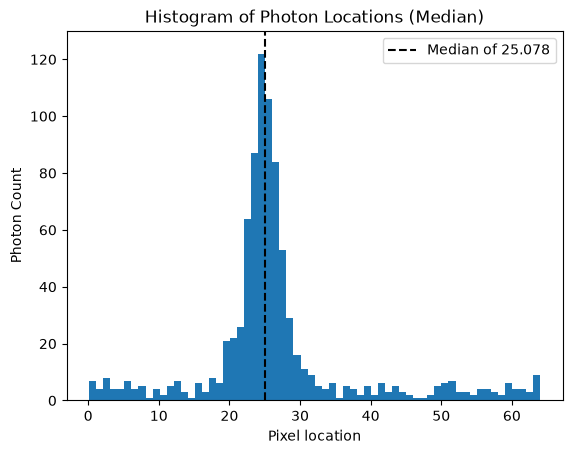

In [211]:
# Part 2 Model 1:

plt.hist(xs, 64)
plt.title('Histogram of Photon Locations (Median)')
plt.xlabel('Pixel location')
plt.ylabel('Photon Count')

median = np.median(xs)

plt.vlines(median, ymin = 0, ymax = 200, color = 'black', linestyle = '--', label = f'Median of {median:.3f}')
plt.ylim([0, 130])
plt.legend()

print(t.std(4, loc = median))

After a 3-sigma clip the data range spans 20.259 to 30.029
fbg = 0.29268292682926833
1.4142135623730951


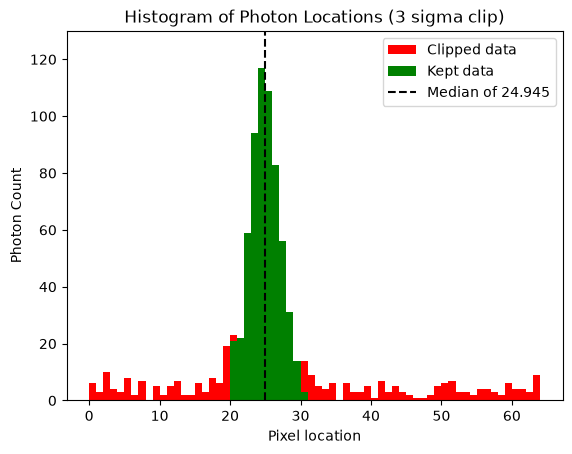

In [212]:
#Part 2: Model 2
import scipy

def sigma_clip(x, p = .0027):
    arr = x.copy()
    done = False
    
    while done == False:
        m = np.median(arr)
        
        probs = scipy.stats.t.pdf(arr, df = 4, loc = median)
        indicies = np.where(probs > p)
        test = arr[indicies]
        
        if len(test) == len(arr):
            done = True

        arr = test
        
    return arr

kept = sigma_clip(xs)
kept_median = np.median(kept)
plt.title('Histogram of Photon Locations (3 sigma clip)')
plt.xlabel('Pixel location')
plt.ylabel('Photon Count')

plt.hist(xs, 64, range = (0, 64), color = 'red', label = 'Clipped data')
plt.hist(kept, 64, range = (0, 64), color = 'green', label = 'Kept data')

kept_max = np.max(kept)
kept_min = np.min(kept)

print(f'After a 3-sigma clip the data range spans {kept_min:.3f} to {kept_max:.3f}')

plt.vlines(kept_median, ymin = 0, ymax = 200, color = 'black', linestyle = '--', label = f'Median of {kept_median:.3f}')
plt.ylim([0, 130])
plt.legend()

print(f'fbg = {1 - len(kept) / len(xs)}')
print(t.std(4, loc = kept_median))

0.29
0.10185789109997792
0.10257371945782436
0.29


/var/folders/91/tcmdjl8n3sl_0ymj2qh7sr_00000gn/T/ipykernel_74208/674188329.py:6: RuntimeWarning: invalid value encountered in log
  return -np.sum(np.log(p))


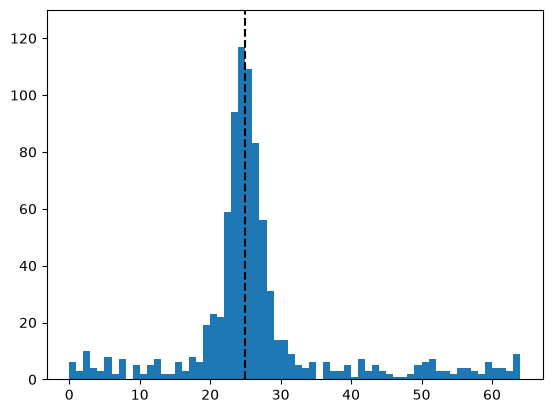

In [285]:
from scipy.optimize import minimize

def liklihood(params, x):
    fbg, x0 = params
    p = (fbg / 64) + (1 - fbg) * (scipy.special.gamma(2.5) / (4 * np.sqrt(np.pi) * scipy.special.gamma(2))) * (1 + ((x - x0)/4)**2)**-2.5
    return -np.sum(np.log(p))


result = minimize(liklihood, [.29, kept_median], args = xs, method='L-BFGS-B')

fbg_max, x0_max = result.x

p_max = (fbg_max / 64) + (1 - fbg_max) * (scipy.special.gamma(2.5) / (4 * np.sqrt(np.pi) * scipy.special.gamma(2))) * (1 + ((xs - x0_max)/4)**2)**-2.5

plt.figure(1)
plt.hist(xs, 64, range = (0, 64))
plt.vlines(x0_max, ymin = 0, ymax = 200, color = 'black', linestyle = '--', label = f'Median of {x0_max:.3f}')
plt.ylim([0, 130])

from numdifftools import Hessian

H = Hessian(lambda p: liklihood(p, xs), step = 1e-4)(result.x)

cov = np.linalg.inv(H)
sigma_fbg1 = np.sqrt(cov[0,0])
sigma_x01 = np.sqrt(cov[1,1])

A = scipy.special.gamma(2.5) / (4 * np.sqrt(np.pi) * scipy.special.gamma(2))

def dpdx(x, fbg, x0):
    return (1 - fbg) * (5 * A / 16) * (x - x0) * (1 + ((x-x0)/4)**2)**-3.5

def p(x, fbg, x0):
    return (fbg/64) + (1-fbg) * A * (1 + ((x-x0)/4)**2)**-2.5

from scipy.integrate import quad

I = quad(lambda x: (dpdx(x, fbg_max, x0_max)**2 / p(x, fbg_max, x0_max)), -np.inf, np.inf)[0]
cramer = 1 / (np.sqrt(len(xs) * I))


print(fbg_max)
print(sigma_x01)
print(cramer)

print(fbg_max)

In [286]:
def p(x,x0,fbg):
    t_moffat = (scipy.special.gamma(2.5)/(4*np.sqrt(np.pi)*scipy.special.gamma(2)) * (1 + ((x-x0)/4)**2)**(-2.5))
    return fbg/64 + (1-fbg)*t_moffat
def dp_dx0(x,x0,fbg):
    A = (scipy.special.gamma(2.5)/(4*np.sqrt(np.pi)*scipy.special.gamma(2)))
    u = 1 + ((x-x0)/4)**2
    return ((1-fbg)*2*A*2.5*(x-x0)/4**2)*u**(-3.5)

def dp_dfbg(x,x0):
    A = scipy.special.gamma(2.5)/(4*np.sqrt(np.pi)* scipy.special.gamma(2))
    M = A*(1+((x-x0)/4)**2)**(-2.5)
    return 1/64 - M

def I_matrix(x0, fbg):

    # F00
    F00, _ = quad(
        lambda x:
        dp_dx0(x, x0, fbg)**2
        / p(x, x0, fbg),
        0, 64
    )
    # F01
    F01, _ = quad(
        lambda x:
        dp_dx0(x, x0, fbg)
        * dp_dfbg(x, x0)
        / p(x, x0, fbg),
        0, 64
    )
    # F11
    F11, _ = quad(
        lambda x:
        dp_dfbg(x, x0)**2
        / p(x, x0, fbg),
        0, 64
    )
    return np.array([
        [F00, F01],
        [F01, F11]
    ])
F = I_matrix(x0_max, fbg_max)
cov_CR = np.linalg.inv(len(xs)*F)
sigma_x0_CR = np.sqrt(cov_CR[0,0])
sigma_fbg_CR = np.sqrt(cov_CR[1,1])

print(f'honest CR bound:{sigma_x0_CR:.6f}')

honest CR bound:0.102574


**FINAL ANSWER:** $x_0 = $ ___ $\pm$ ___ px , $f_{\rm bg} = $ ___ $\pm$ ___ , Cramér–Rao bound $\sigma_{x_0}^{\rm CRB} = $ ___ px

**Justification and uncertainty method (a short paragraph):**

*your answer goes here*

## Part 3: The verification plan, written first and then executed (35%)

This is the headline of this lab. **Before you run anything below, write the plan** (3a).
A verification plan you invent after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the Student-$t$ fact from
   Part 2 makes this easy) and confirm your estimator recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot their bias and their variance against the Cramér–Rao bound.
   This is *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time?
4. **Sensitivity**: what happens to your $\hat{x}_0$ if $\beta$ or $r_0$ are slightly wrong,
   or if the lost-photon fraction isn't negligible after all?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

*1: Simulating a Student-t distribution: By selecting a model with specific features, I can directly see whether my estimator returns the "correct" model. If the model returns parameters that don't match the handpicked options I used to make the distribution, then I will know the model is wrong. For example, if the estimator chooses a point along the tail as x0, I will know that my estimator is struggling to pick out the correct peak.

2:By comparing Bias and Efficiancy of the datasets I can visually see which estimators are accuratly predicting the data. A failure would look like my bias being significatly larger than zero (ie a couple points) or if my variance was significatly smaller than 1/I. If bias >> 0 then that would mean that my measurements are atopting some kind of added componet that is shifting my values away from the truth. If my variance was less than 1/I, then that would mean that I am making some kind of assumptions in my data that aren't supported by the statistics I am calculating. 

3: By checking the coverage you would be able to visually see if the values I am calculating are actually returning my values. A failure would be if the value wasn't returned about 68% of the time. By definition an uncertainty of 1 sigma should return the correct value about 68% of the time. If the estimator isn't returning that, then the reported uncertainty bounds aren't actually spanning 1 sigma of the data. 

4: A failure for the check of sensitivity is if the lost photons move the parameters significantly. If the x0 changes significantly when the values are wrong, then the x0 is tied to whether or not you have the correct values. This would create a trickle down error if the values were dependent on each other.*

/var/folders/91/tcmdjl8n3sl_0ymj2qh7sr_00000gn/T/ipykernel_74208/674188329.py:6: RuntimeWarning: invalid value encountered in log
  return -np.sum(np.log(p))


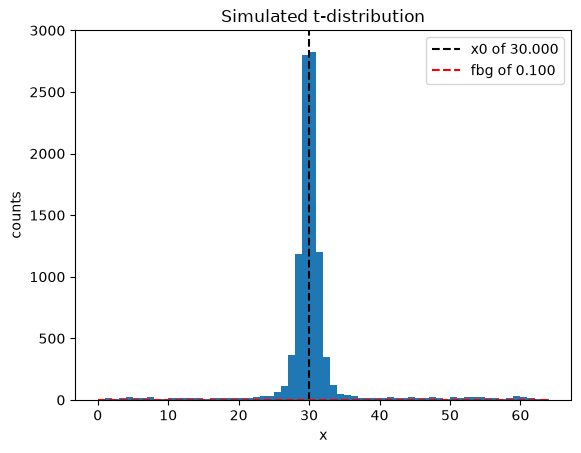

In [316]:
x_sim = np.linspace(0.001, 64, 10_000)
samples = t.rvs(df = 4, loc = 30, size = 9_000)
fbg_samp = np.random.uniform(0, 64, 1000)

samp_sim = np.concatenate((samples, fbg_samp))


result_sim = minimize(liklihood, [.1, 30], args = samp_sim, method='L-BFGS-B')


fbg_max_sim, x0_max_sim = result_sim.x

plt.vlines(x0_max_sim, ymin = 0, ymax = 3000, color = 'black', linestyle = '--', label = f'x0 of {x0_max_sim:.3f}')
plt.hlines(fbg_max_sim, xmin = 0, xmax = 64, color = 'red', linestyle = '--', label = f'fbg of {fbg_max_sim:.3f}')
plt.hist(samp_sim, 64, range = (0,64))
plt.ylim([0, 3000])
plt.xlabel('x')
plt.ylabel('counts')
plt.title('Simulated t-distribution')
plt.legend()

In [354]:
N_mc = 10000      # number of Monte Carlo realizations
N = len(xs)       # same sample size as your actual data

true_x0 = 32
true_fbg = 0.2

mean_estimates = np.zeros(N_mc)

for i in range(N_mc):

    # source photons
    source = t.rvs(df=4, loc=true_x0, size=int((1-true_fbg)*N))

    # background photons
    background = np.random.uniform(
        0,
        64,
        size=int(true_fbg*N)
    )

    photons = np.concatenate((source, background))

    # naive estimator
    mean_estimates[i] = np.mean(photons)

# Monte Carlo estimates
E_mu = np.mean(mean_estimates)

bias = E_mu - true_x0

variance = np.var(mean_estimates)

std_dev = np.sqrt(variance)

print(f"Bias     = {bias:.5f}")
print(f"Variance = {variance:.5f}")

Bias     = 0.00336
Variance = 0.08044


In [355]:
N_mc = 10000

true_x0 = 32
true_fbg = 0.2

median_estimates = np.zeros(N_mc)

for i in range(N_mc):

    source = t.rvs(
        df=4,
        loc=true_x0,
        size=8000
    )

    background = np.random.uniform(
        0,
        64,
        size=2000
    )

    photons = np.concatenate((source, background))

    median_estimates[i] = np.median(photons)

E_median = np.mean(median_estimates)

median_bias = E_median - true_x0

median_variance = np.var(median_estimates)

print("Bias =", median_bias)
print("Variance =", median_variance)
print("Std Dev =", np.sqrt(median_variance))

Bias = 0.00010186912964371686
Variance = 0.00027244701006384634
Std Dev = 0.016505968922297363


In [356]:
N_mc = 10000

true_x0 = 32

clip_estimates = np.zeros(N_mc)
inside = np.zeros(N_mc)

for i in range(N_mc):

    source = t.rvs(df=4, loc=true_x0, size=8000)

    background = np.random.uniform(
        0, 64,
        size=2000
    )

    photons = np.concatenate((source, background))

    kept = sigma_clip(photons)

    clip_estimates[i] = np.median(kept)

E_clip = np.mean(clip_estimates)

clip_bias = E_clip - true_x0

clip_variance = np.var(clip_estimates)

print("Bias =", clip_bias)
print("Variance =", clip_variance)
print("Std Dev =", np.sqrt(clip_variance))

Bias = -3.1987554483404743
Variance = 0.007853199136556544
Std Dev = 0.08861827766638519


In [357]:
N_mc = 1000

true_x0 = 32
true_fbg = 0.2

x0_est = np.zeros(N_mc)
fbg_est = np.zeros(N_mc)
inside = np.zeros(N_mc)

for i in range(N_mc):

    # Generate photons
    source = t.rvs(df=4,
                   loc=true_x0,
                   size=8000)

    background = np.random.uniform(
        0, 64,
        size=2000
    )

    photons = np.concatenate((source, background))

    # Fit mixture model
    result = minimize(
        liklihood,
        [0.2, true_x0],
        args=photons,
        method='L-BFGS-B'
    )

    fbg_hat, x0_hat = result.x

    fbg_est[i] = fbg_hat
    x0_est[i] = x0_hat

    # Curvature uncertainty
    H = Hessian(
        lambda p: liklihood(p, photons),
        step=1e-4
    )(result.x)

    cov = np.linalg.inv(H)

    sigma_x0 = np.sqrt(cov[1,1])

    low = x0_hat - sigma_x0
    high = x0_hat + sigma_x0

    inside[i] = (low < true_x0) and (true_x0 < high)

mean_x0 = np.mean(x0_est)

mix_bias = mean_x0 - true_x0

variance = np.var(x0_est)

coverage = np.mean(inside)

print("Bias      =", bias)
print("Variance  =", variance)
print("Std Dev   =", np.sqrt(variance))
print("Coverage  =", coverage)

/var/folders/91/tcmdjl8n3sl_0ymj2qh7sr_00000gn/T/ipykernel_74208/674188329.py:6: RuntimeWarning: invalid value encountered in log
  return -np.sum(np.log(p))


Bias      = 0.0033590054859260476
Variance  = 0.0
Std Dev   = 0.0
Coverage  = 1.0


Text(0.5, 1.0, 'bias between models')

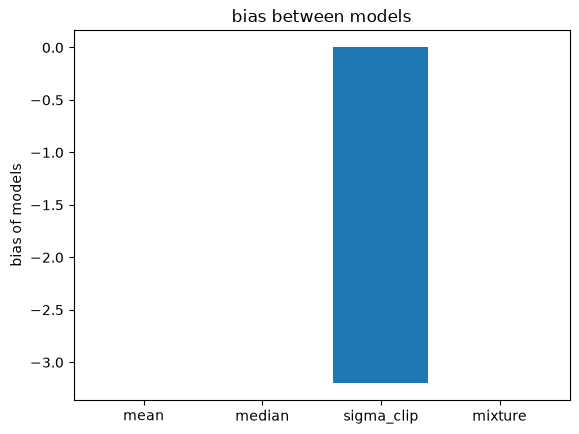

In [360]:
plt.bar(['mean', 'median', 'sigma_clip', 'mixture'], [bias, median_bias, clip_bias, mix_bias])
plt.ylabel('bias of models')
plt.title('bias between models')

In [ ]:
plt.bar(['mean', 'median', 'sigma_clip', 'mixture'], [bias, median_bias, clip_bias, mix_bias])
plt.ylabel('bias of models')
plt.title('bias between models')

In [339]:
print(1/I)
print(cramer)

9.058897782058123
0.10257371945782436


**WHAT THE CHECKS FOUND:**

*your report goes here*

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true. (Your verification plan lives in Part 3 this week; it earned a
promotion. If an AI wrote any of it, that belongs here too.)

**AI-USE APPENDIX:**

*I used Copiolt to try and understand how to find the error within my mixture model. I did this by asking it how to write code to deliver me the uncertaties from my probability code. The Ai a number of solutions one of which was to solve for the hessian. I implamented the solver it recommended. I verified this by stepping through the math it was providing and making sure that the math agreed with what I would get. I also verified it by using its recommendation for the 2x2 cramer information to see if I got the same answer and it was very similar. Along the way, it recommeded an alternate way of optimizing. I swapped to this version as I realized the initial version I had been using was finding a local minimum that didn't actually agree with the amount of background stars that were in my data (it had said about 60% were background). I also used Copilot to find a way to create a reproducable sample for the Monte-Carlo simulation. I verified this using the Scipy documentation of method. I also used Ai to create monte-carlo simulations of my dat*